# Credit Risk Dataset - Exploratory Data Analysis
---

## Project Overview
Analyze loan applicant data to identify key risk factors and prepare for predictive modeling.

**Business Context:** Understanding which borrowers are likely to default helps financial institutions minimize losses, set appropriate interest rates, and make informed lending decisions.



## 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import math
import seaborn as sns
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv('credit_risk_dataset.csv')
print(f'{df.shape[0]:,} Rows X {df.shape[1]:,} Columns')
print(f'\nDataset Information')
print(f'{df.info()}')

32,581 Rows X 12 Columns

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory 

In [3]:
df.head(10)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3


## 2. Missing Value Analysis and Treatment

**Strategy:** Instead of dropping rows (which loses data), we impute missing values:
- Numerical features: Median 
- Categorical features: Most frequent value 

In [3]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

if 'loan_status' in numerical_cols:
    numerical_cols.remove('loan_status')
elif 'loan_status' in categorical_cols:
    categorical_cols.remove('loan_status')

print(numerical_cols)
print(categorical_cols)


['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


In [4]:
print('Checking if any column contains missing values.')
print(df.isnull().any()[df.isnull().any() == True])

num_imputer = SimpleImputer(strategy='median')
df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

print('\nAfter imputing missing values')
print(df.isnull().any()[df.isnull().any() == True])

Checking if any column contains missing values.
person_emp_length    True
loan_int_rate        True
dtype: bool

After imputing missing values
Series([], dtype: bool)


## 3. Target Variable Analysis

Understanding the default rate and class distribution is critical for:
- Identifying class imbalance
- Selecting appropriate evaluation metrics
- Deciding if resampling techniques are needed

Percentage of non-defaults and defautls

78.18% : Non Defaults
21.82% : Defaults


Text(0.5, 1.0, 'Pie Chart: Non Defaults vs Defaults')

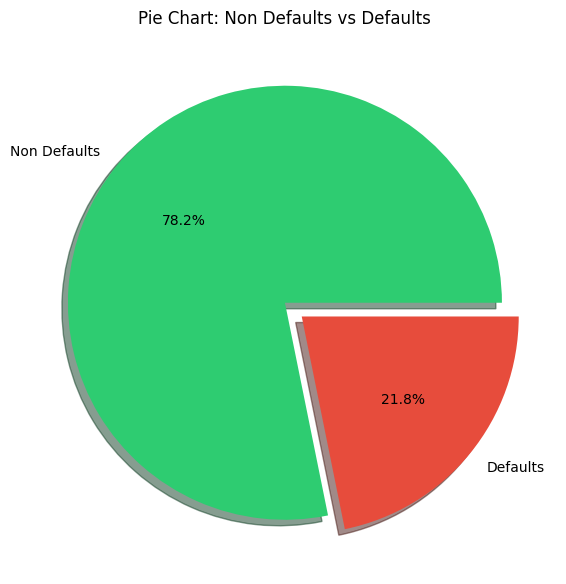

In [5]:

percentage_target_count = df['loan_status'].value_counts(normalize=True)*100

print('Percentage of non-defaults and defautls\n')
print(f'{percentage_target_count[0]:.2f}% : Non Defaults')
print(f'{percentage_target_count[1]:.2f}% : Defaults')

plt.figure(figsize=(7,8))
plt.pie(percentage_target_count.values, labels = ['Non Defaults', 'Defaults'], explode=(0,0.1), shadow=True,
        colors=['#2ecc71', '#e74c3c'],autopct='%1.1f%%')
plt.title('Pie Chart: Non Defaults vs Defaults')

## 4. Numerical Features Analysis

Analyzing distributions helps identify:
- Skewness requiring transformation
- Scale differences requiring normalization
- Potential outliers

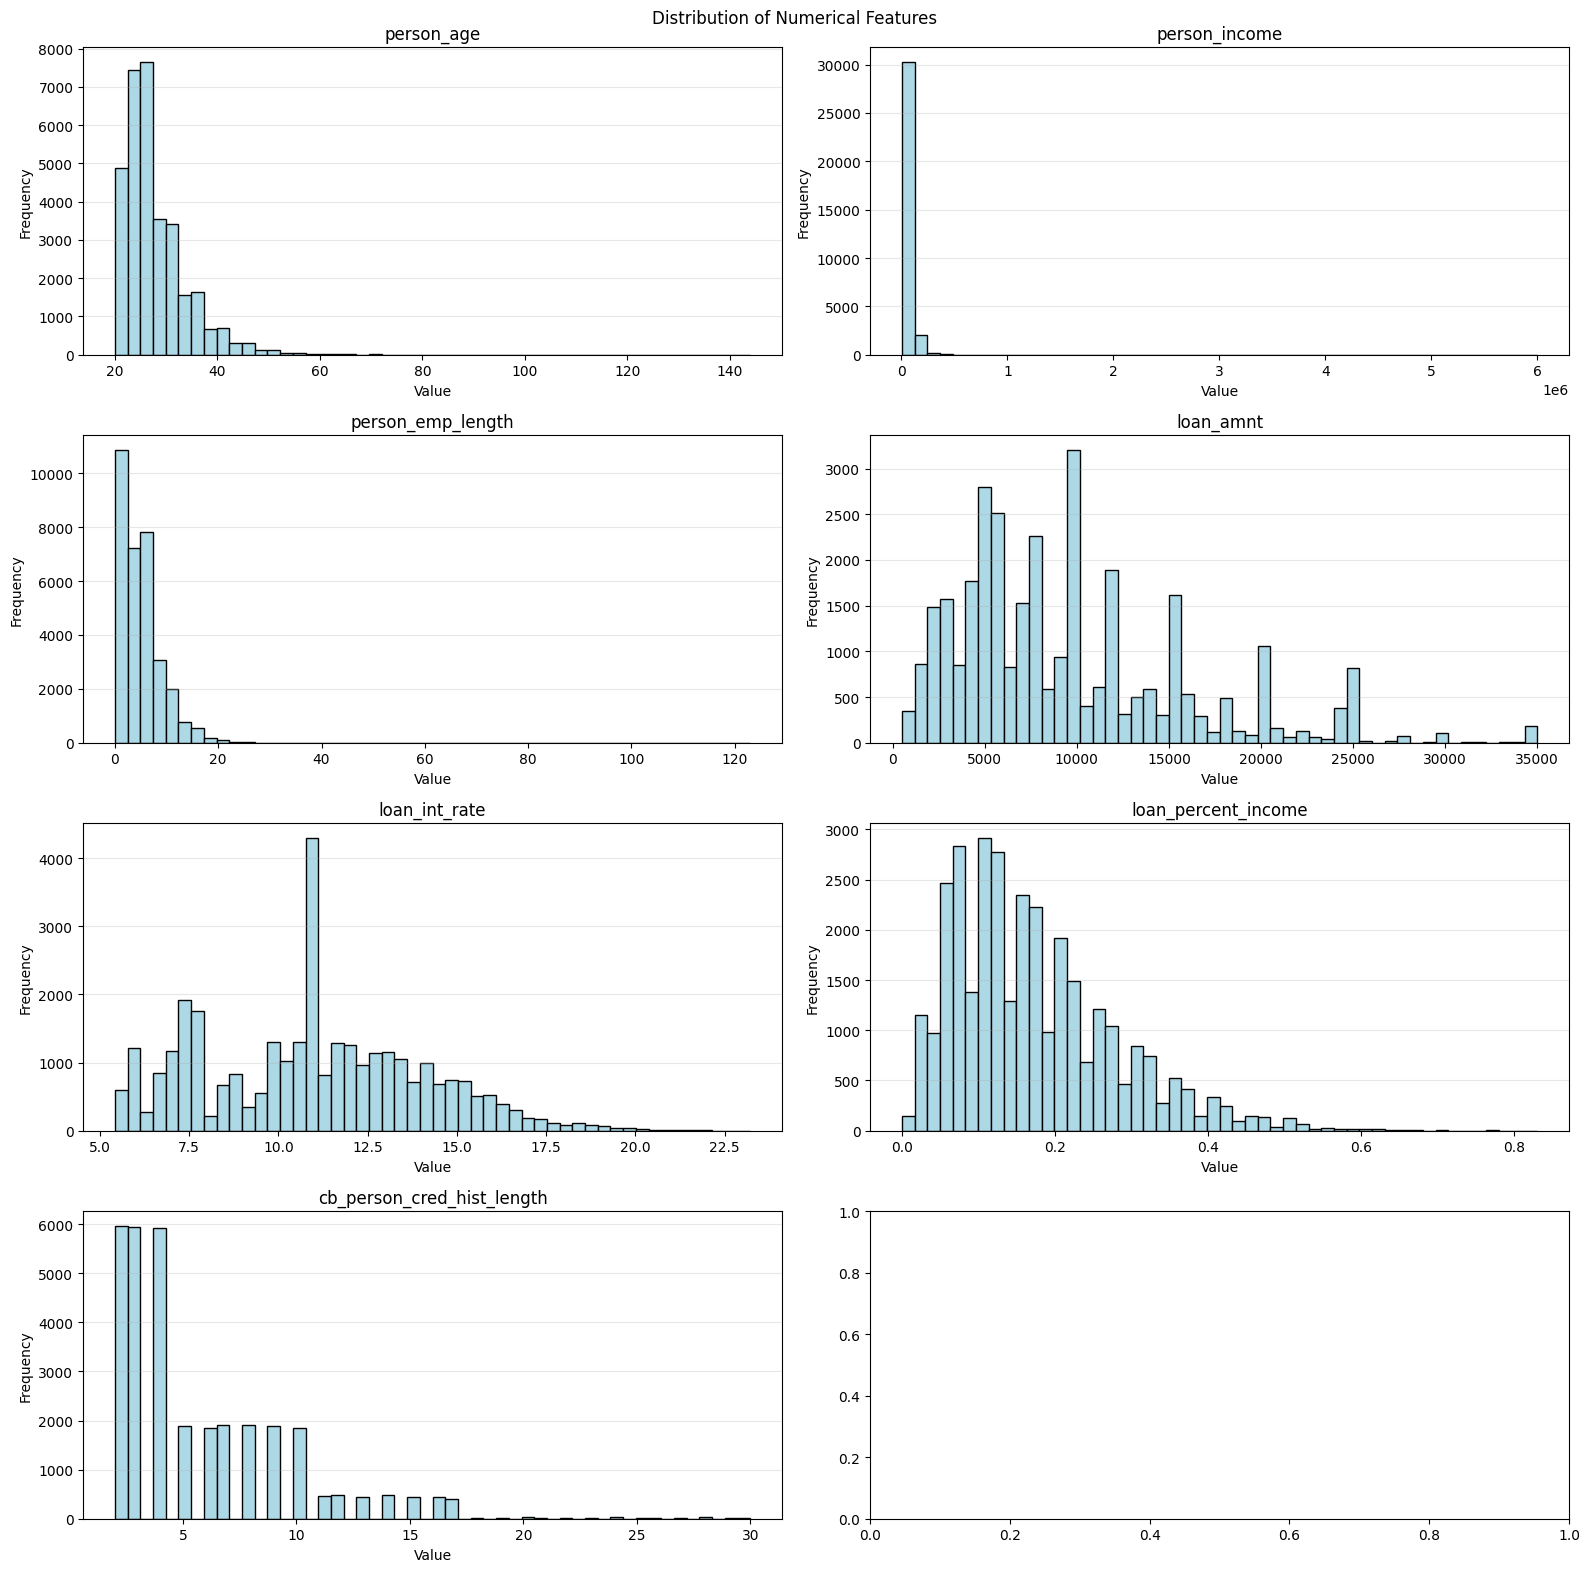

In [6]:
cols = 2
rows = math.ceil(len(numerical_cols)/2)

fig, axes = plt.subplots(rows, cols, figsize = (16, rows * 4))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df[col], bins = 50, color='Lightblue', edgecolor='Black')
    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)


plt.suptitle('Distribution of Numerical Features')
plt.tight_layout()
plt.show()

## 5. Categorical Features Analysis

In [13]:
for col in categorical_cols:
    print(f'\n{df[col].value_counts()}')


person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64


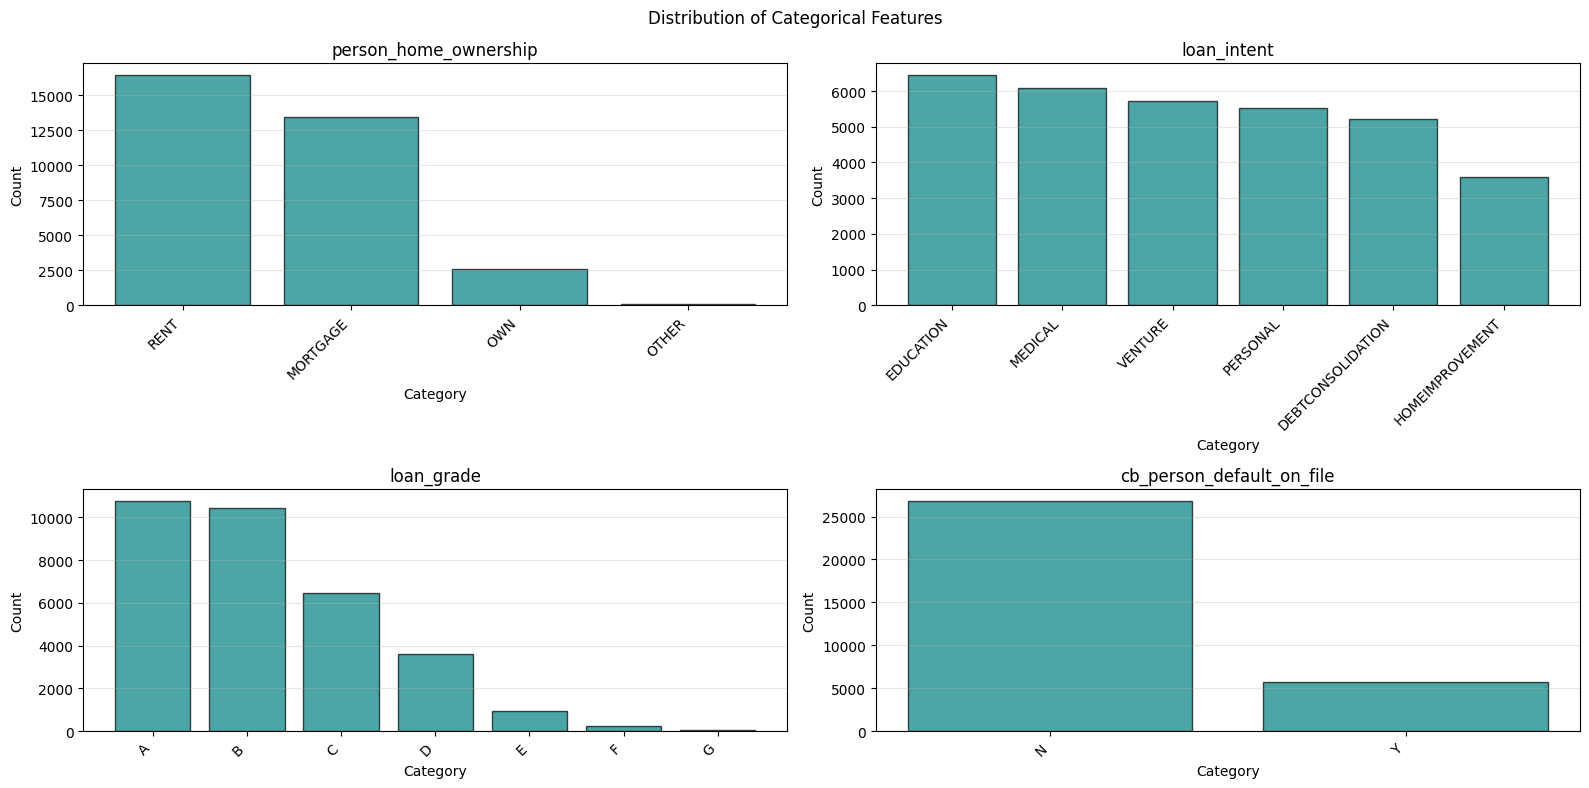

In [8]:
cols = 2
rows = math.ceil(len(categorical_cols)/2)

fig, axes = plt.subplots(rows, cols, figsize = (16, rows * 4))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    value_counts = df[col].value_counts()
    axes[idx].bar(range(len(value_counts)), value_counts.values, color= 'Teal', edgecolor= 'Black', alpha=0.7)
    axes[idx].set_xticks(range(len(value_counts)))
    axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel('Category')
    axes[idx].set_ylabel('Count')
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Distribution of Categorical Features')
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

Correlation analysis reveals:
- Which features are most related to loan default
- Multicollinearity between features
- Redundant features that could be removed

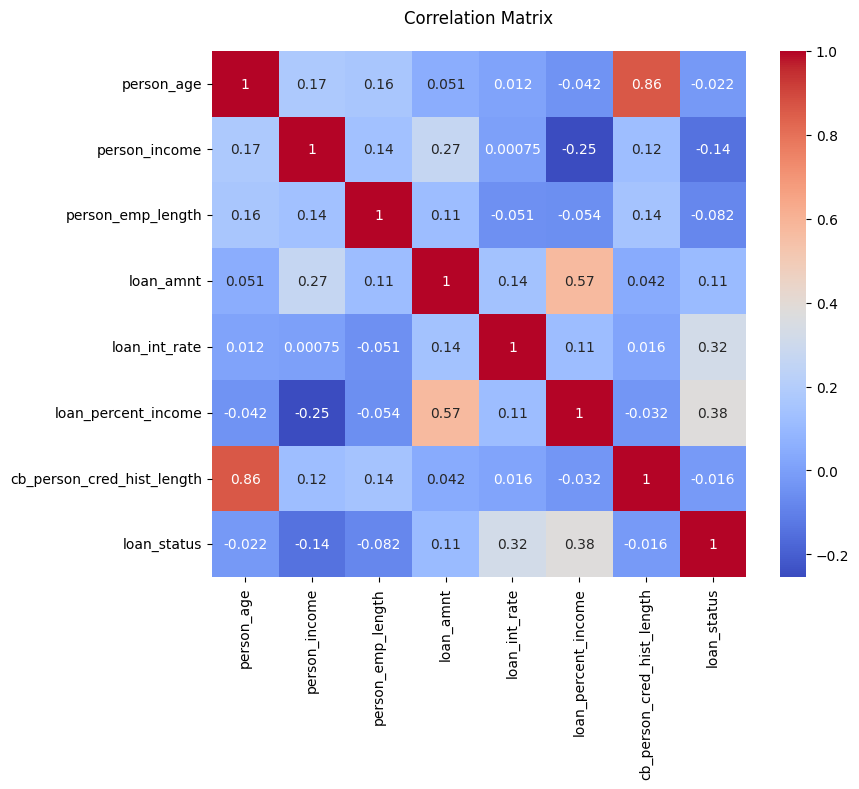

In [9]:
corr_matrix = df[numerical_cols + ['loan_status']].corr()

plt.figure(figsize=(9, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix', pad=20)
plt.tight_layout()
plt.show()

## 7. Bivariate Analysis: Features vs Target

Comparing feature distributions between defaulters and non-defaulters helps:
- Validate feature importance
- Identify patterns for feature engineering
- Understand business drivers of default

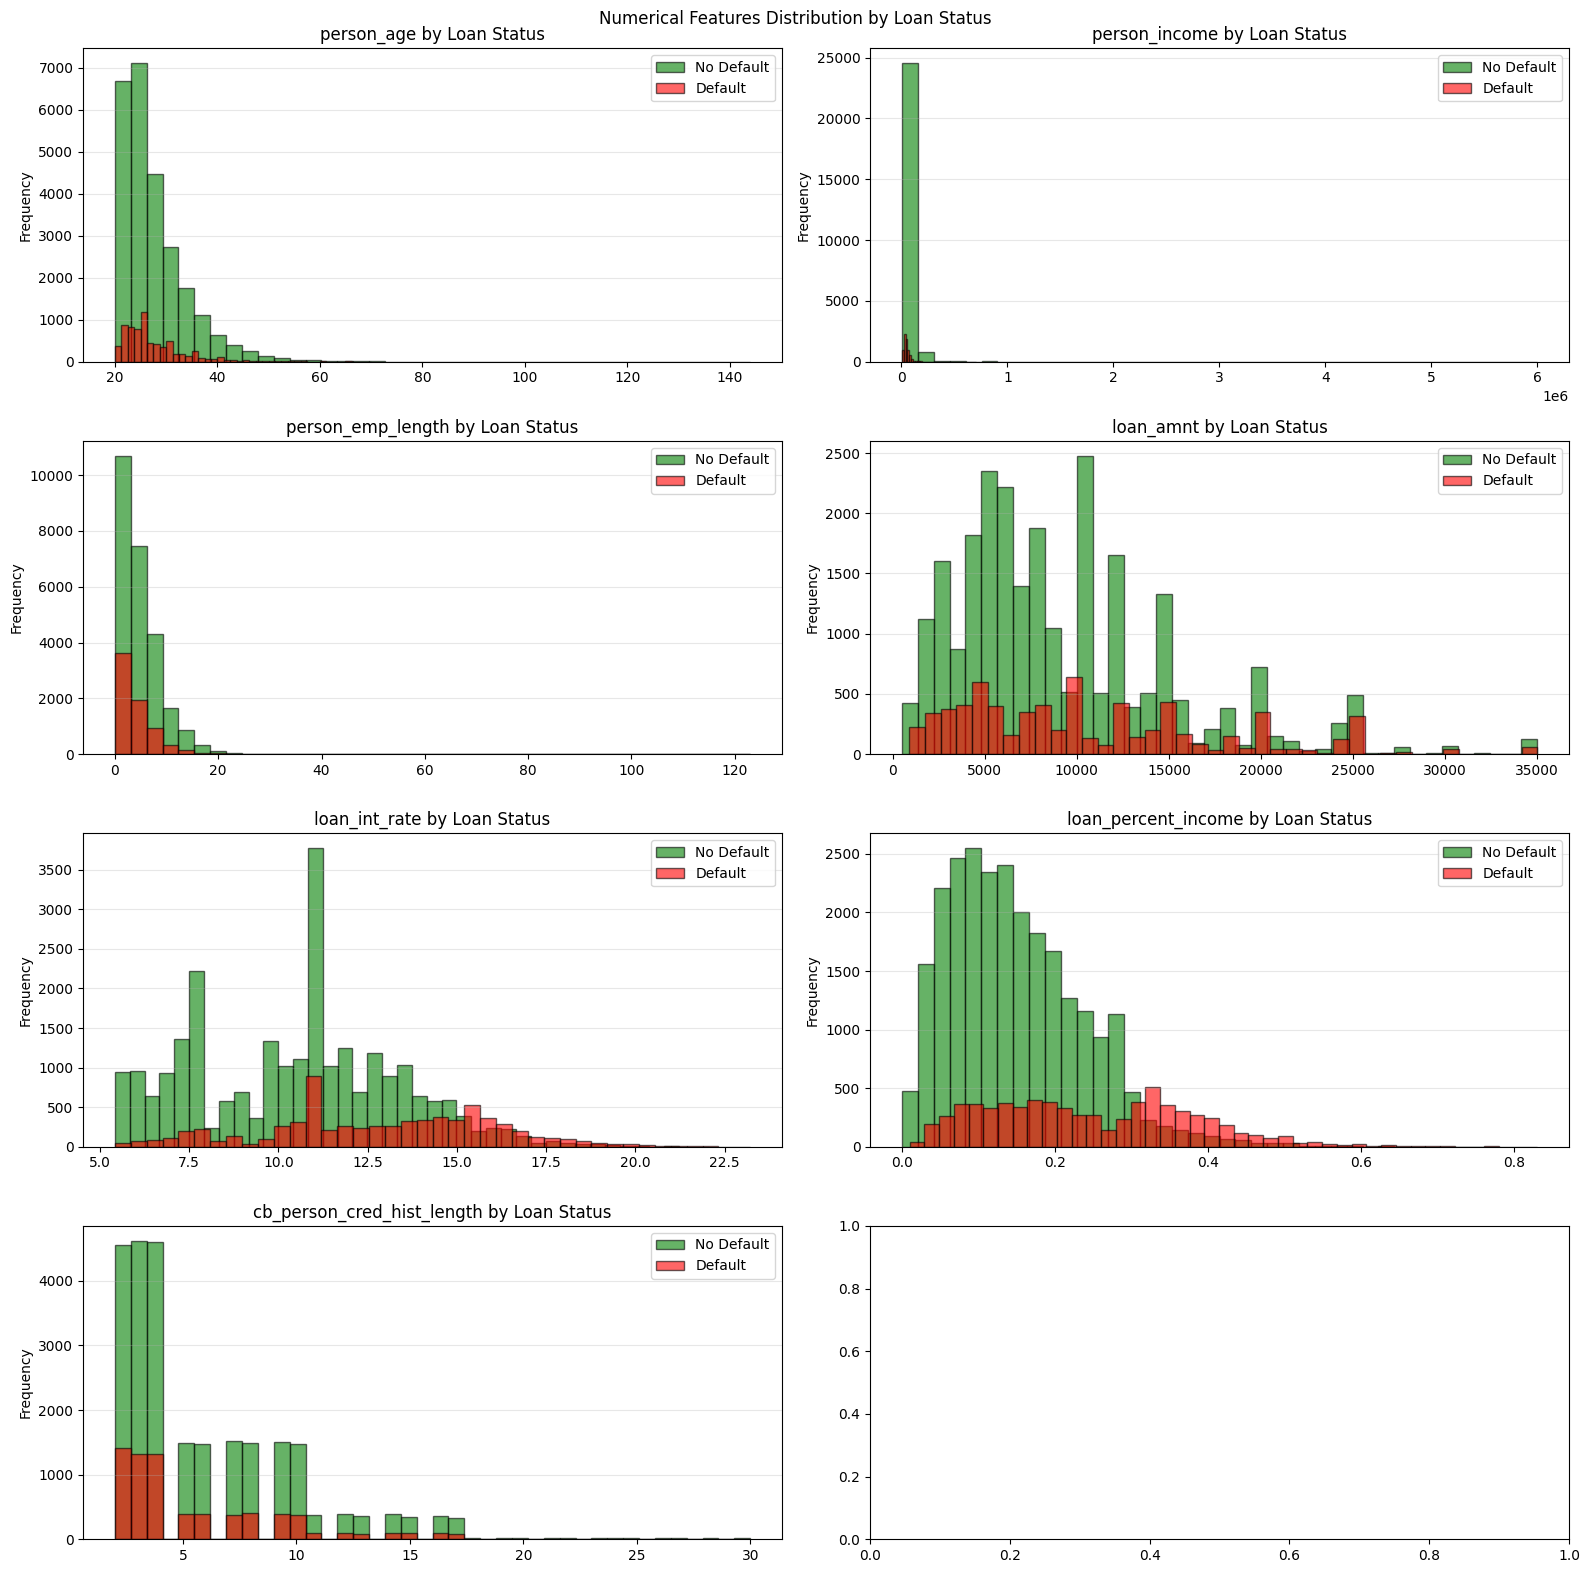

In [10]:
cols = 2
rows = math.ceil(len(numerical_cols)/2)

fig, axes = plt.subplots(rows, cols, figsize = (16, rows * 4))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):

    no_default = df[df['loan_status'] == 0][col].dropna()
    default = df[df['loan_status'] == 1][col].dropna()

    axes[idx].hist(no_default, bins=40, alpha=0.6, label='No Default', color='green', edgecolor='black')
    axes[idx].hist(default, bins=40, alpha=0.6, label='Default', color='red', edgecolor='black')

    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{col} by Loan Status')
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Numerical Features Distribution by Loan Status')
plt.tight_layout()
plt.show()


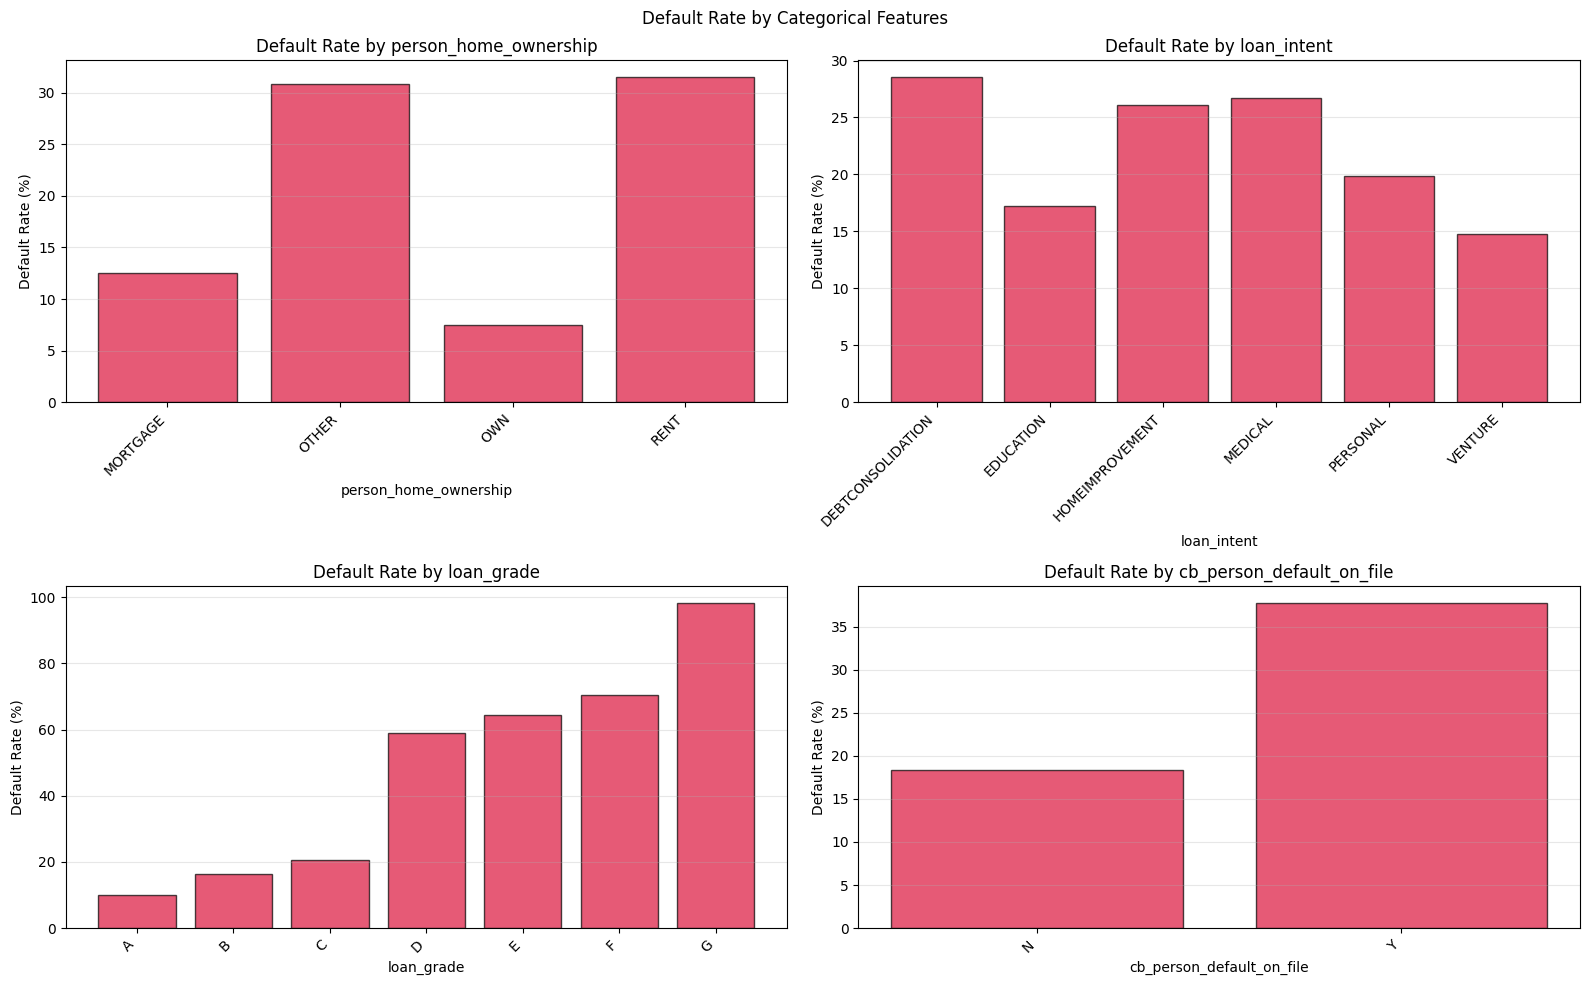

In [11]:
cols = 2
rows = math.ceil(len(categorical_cols)/2)

fig, axes = plt.subplots(rows, cols, figsize = (16, rows * 5))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    default_rate = df.groupby(col)['loan_status'].mean()*100
    axes[idx].bar(range(len(default_rate)), default_rate.values, color='crimson', alpha=0.7, edgecolor='black')
    axes[idx].set_xticks(range(len(default_rate)))
    axes[idx].set_xticklabels(default_rate.index, rotation=45, ha='right')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Default Rate (%)')
    axes[idx].set_title(f'Default Rate by {col}')
    axes[idx].grid(axis='y', alpha=0.3)

plt.suptitle('Default Rate by Categorical Features')
plt.tight_layout()
plt.show()

## 8. Key Insights and Next Steps

### Summary
- Successfully handled missing values without data loss using median/mode imputation
- Analyzed distributions of all features and their relationship with default
- Correlation analysis revealed key predictors of loan default

### Recommendations for Modeling
1. **Feature scaling:** Standardize numerical features
2. **Model selection:** Test Logistic Regression, XGBoost, Random Forest
3. **Evaluation metrics:** Prioritize ROC-AUC and precision-recall